<a href="https://colab.research.google.com/github/Z4nata/CalculoNumerico/blob/main/Atividade_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Cálculo Numérico — Atividade Prática IV

## Animação da Eliminação de Gauss

**Disciplina:** Cálculo Numérico — Prof. Raquel J. Lobosco  
**Aluno:** Felipe Zanata - 176287

Resolve o sistema $A\mathbf{x} = \mathbf{b}$ por eliminação de Gauss (sem pivoteamento) seguida de retrossubstituição e gera uma animação com cada passo: o pivô de cada coluna, o multiplicador, a operação entre linhas e a conferência da solução no sistema original.

## Parte 1 — O sistema

$$\begin{cases} 2x + y - z = 8 \\ -3x - y + 2z = -11 \\ -2x + y + 2z = -3 \end{cases}$$

Para animar outro sistema, basta trocar `A` e `b` (e a lista `variaveis`, se não for 3×3).

In [1]:
import numpy as np
import matplotlib
from matplotlib import font_manager
from matplotlib.backends.backend_agg import FigureCanvasAgg
from matplotlib.colors import to_rgb
from matplotlib.figure import Figure
from matplotlib.patches import Circle, FancyBboxPatch
from PIL import Image
from IPython.display import Image as ImagemNotebook, display


#    2x +  y -  z =   8
#   -3x -  y + 2z = -11
#   -2x +  y + 2z =  -3
# solucao esperada: x = 2, y = 3, z = -1

A = np.array([[ 2.0,  1.0, -1.0],
              [-3.0, -1.0,  2.0],
              [-2.0,  1.0,  2.0]])
b = np.array([8.0, -11.0, -3.0])

variaveis = ["x", "y", "z"]   # um nome por incognita
n = len(b)

FPS = 20
ARQUIVO_GIF = "eliminacao_gauss.gif"


## Parte 2 — Aparência e funções auxiliares

Cores, fontes e tempos da animação, as funções que escrevem os números com vírgula decimal dentro das fórmulas e as curvas de suavização (*easing*) usadas nas transições.

In [2]:
FUNDO = "#0d1117"
PONTOS = "#1a2130"        # grade de pontos do fundo
PAINEL = "#121822"
PAINEL_BORDA = "#232c3a"
CELULA = "#161d29"
CELULA_BORDA = "#273142"
TEXTO = "#e6ebf2"
SUAVE = "#7a869a"
APAGADO = "#3b4658"

AMARELO = "#ffc857"   # pivo
AZUL = "#4ea1ff"      # linha que esta mudando
VERDE = "#34d399"     # zeros e resultado
ROXO = "#a78bfa"      # retrossubstituicao

NOMES_DAS_FASES = ["Eliminação", "Retrossubstituição", "Resultado"]
COR_DA_FASE = [AZUL, ROXO, VERDE]

instaladas = {f.name for f in font_manager.fontManager.ttflist}
FONTE = next(f for f in ["Segoe UI", "Helvetica Neue", "Arial", "Liberation Sans", "DejaVu Sans"]
             if f in instaladas)
NEGRITO = "semibold" if FONTE == "Segoe UI" else "bold"
matplotlib.rcParams["font.family"] = FONTE
matplotlib.rcParams["mathtext.fontset"] = "cm"   # formulas com cara de LaTeX

# tempos (segundos)
T_COR = 0.45          # troca de cor das celulas entre um passo e outro
ENTRADA = 0.45        # cada linha do painel aparecendo
STAGGER = 0.06        # atraso entre uma linha do painel e a seguinte
SAIDA = 0.2           # painel sumindo no fim do passo (sair e mais rapido que entrar)
T_PULSO = 0.7         # anel que se expande em volta de uma celula
T_ROLAR = 0.5         # numero antigo sobe e some, o novo entra por baixo
T_PROGRESSO = 0.6
# operacao de linha L_i <- L_i - m L_k
T_LEVANTA = 0.25      # uma copia de L_k se levanta
T_MULTIPLICA = 0.8    # a copia vira m L_k
T_DESCE = 1.45        # a copia desce ate L_i (leva 0.8 s)
T_FUNDE = 2.35        # a copia se funde em L_i e os valores mudam
# retrossubstituicao
T_POP = 1.0           # valor novo entra no vetor solucao


def fmt(v: float, casas: int = 4) -> str:
    v = round(float(v), casas) + 0.0   # + 0.0 transforma -0.0 em 0.0
    return f"{v:g}"


def tex(v: float) -> str:
    """Numero para usar dentro de $...$ com virgula decimal: 1.5 -> 1{,}5"""
    return fmt(v).replace(".", "{,}")


def texp(v: float) -> str:
    """Negativos entre parenteses, para as contas ficarem legiveis."""
    return f"({tex(v)})" if round(v, 4) < 0 else tex(v)


def a(i: int, j: int) -> str:
    """a(2, 1) -> 'a_{21}' (indices comecando em 1, como no caderno)"""
    return f"a_{{{i}{j}}}"


def equacao_tex(coefs, lado_direito) -> str:
    """[2, 1, -1], 8 -> '2x + y - z = 8'"""
    termos = []
    for c, var in zip(coefs, variaveis):
        c = round(float(c), 4)
        if c == 0:
            continue
        valor = var if abs(c) == 1 else tex(abs(c)) + var
        if not termos:
            termos.append(("-" if c < 0 else "") + valor)
        else:
            termos.append(("- " if c < 0 else "+ ") + valor)
    return " ".join(termos) + " = " + tex(lado_direito)


def limita(s):
    return min(max(s, 0.0), 1.0)


def ease_out(s):
    """Comeca rapido e freia: para coisas entrando na tela."""
    return 1 - (1 - limita(s)) ** 5


def ease_in_out(s):
    """Acelera e freia: para coisas que se movem ou mudam de cor."""
    s = limita(s)
    return 16 * s ** 5 if s < 0.5 else 1 - (-2 * s + 2) ** 5 / 2


def rgb(cor):
    return np.array(to_rgb(cor)) if isinstance(cor, str) else np.asarray(cor, dtype=float)


def mistura(c1, c2, s):
    return rgb(c1) * (1 - s) + rgb(c2) * s


def estilo(cor, forca_fundo, forca_borda=1.0, brilho=0.0):
    return {"fundo": mistura(CELULA, cor, forca_fundo),
            "borda": mistura(CELULA_BORDA, cor, forca_borda),
            "cor": rgb(cor), "brilho": brilho}


ESTILOS = {
    "normal":     {"fundo": rgb(CELULA), "borda": rgb(CELULA_BORDA), "cor": rgb(CELULA_BORDA), "brilho": 0.0},
    "pivo":       estilo(AMARELO, 0.22, brilho=1.0),
    "linha_pivo": estilo(AMARELO, 0.07, 0.45),
    "alvo":       estilo(AZUL, 0.20, brilho=0.7),
    "zero":       estilo(VERDE, 0.20, brilho=0.8),
    "retro":      estilo(ROXO, 0.18, brilho=0.5),
}
COR_ROTULO = {"normal": SUAVE, "pivo": AMARELO, "linha_pivo": AMARELO,
              "alvo": AZUL, "zero": VERDE, "retro": ROXO}


def mistura_estilo(e1, e2, s):
    return {chave: e1[chave] * (1 - s) + e2[chave] * s for chave in e1}


## Parte 3 — Eliminação de Gauss

Para cada coluna $k$, o pivô é $a_{kk}$. Cada linha $i$ abaixo dele recebe

$$m_{ik} = \frac{a_{ik}}{a_{kk}}, \qquad L_i \leftarrow L_i - m_{ik}\,L_k,$$

o que zera $a_{ik}$. Cada passo fica guardado como um *quadro* com o que deve aparecer na tela. Sem pivoteamento, um pivô nulo interrompe o método.

In [3]:
# Cada quadro diz o que aparece na tela naquele passo:
#   cores    (linha, coluna) ou ("sol", j) -> estilo da celula
#   zeros    celulas que ficam verdes em t_zeros
#   atrasos  quanto cada celula espera antes de mudar de cor
#   pulsos   (celula, instante, cor) de um anel que se expande
#   itens    linhas do painel da direita

quadros = []


def novo_quadro(fase, titulo, itens, M, segundos, **extras):
    q = {"fase": fase, "titulo": titulo, "itens": itens, "M": M.copy(), "segundos": segundos,
         "M_antes": None, "cores": {}, "zeros": [], "t_zeros": 0.0, "atrasos": {},
         "pulsos": [], "solucao": [None] * n, "nova": None, "fantasma": None, "intro": False}
    q.update(extras)
    if q["M_antes"] is not None:
        q["M_antes"] = q["M_antes"].copy()
    q["solucao"] = list(q["solucao"])
    quadros.append(q)


M = np.column_stack([A, b])   # matriz aumentada [A | b]

novo_quadro(0, "O sistema", [
    *[("formula", f"${equacao_tex(A[i], b[i])}$") for i in range(n)],
    ("espaco", 0.03),
    ("suave", "Cada equação vira uma linha"),
    ("suave", r"da matriz aumentada $[A\,|\,b]$."),
], M, segundos=5, intro=True)

for k in range(n - 1):
    pivo = M[k, k]
    if abs(pivo) < 1e-12:
        raise ValueError(f"Pivo nulo na linha {k + 1}: sem pivoteamento o metodo para aqui.")

    abaixo = [f"${a(i + 1, k + 1)}$" for i in range(k + 1, n)]
    abaixo = abaixo[0] if len(abaixo) == 1 else ", ".join(abaixo[:-1]) + " e " + abaixo[-1]
    cores = {(k, k): "pivo"}
    cores.update({(i, k): "alvo" for i in range(k + 1, n)})
    novo_quadro(0, f"Pivô da coluna {k + 1}", [
        ("texto", "O pivô é o elemento da diagonal"),
        ("formula", f"${a(k + 1, k + 1)} = {tex(pivo)}$"),
        ("espaco", 0.02),
        ("texto", f"Com ele vamos zerar {abaixo},"),
        ("texto", "um de cada vez, fazendo"),
        ("formula", rf"$L_i \leftarrow L_i - m_{{i{k + 1}}}\,L_{k + 1}$"),
    ], M, segundos=4, cores=cores,
        atrasos={(i, k): 0.15 + 0.08 * (i - k) for i in range(k + 1, n)},
        pulsos=[((k, k), 0.25, AMARELO)])

    for i in range(k + 1, n):
        m = M[i, k] / pivo
        m_nome = f"m_{{{i + 1}{k + 1}}}"

        # 4a) o multiplicador
        novo_quadro(0, f"Multiplicador ${m_nome}$", [
            ("fracao", rf"${m_nome} = \dfrac{{{a(i + 1, k + 1)}}}{{{a(k + 1, k + 1)}}}"
                       rf" = \dfrac{{{tex(M[i, k])}}}{{{tex(pivo)}}} = {tex(m)}$"),
            ("espaco", 0.03),
            ("suave", f"Operação na linha {i + 1}:"),
            ("formula", rf"$L_{i + 1} \leftarrow L_{i + 1} - {m_nome}\,L_{k + 1}$"),
        ], M, segundos=4, cores={(k, k): "pivo", (i, k): "alvo"},
            pulsos=[((i, k), 0.2, AZUL), ((k, k), 0.3, AMARELO)])

        # 4b) a operacao de linha: L_i <- L_i - m * L_k
        M_antes = M.copy()
        M[i, :] = M[i, :] - m * M[k, :]
        M[i, k] = 0.0   # zera exato (evita sobrar algo como 1e-16)

        contas = []
        for j in range(k, n + 1):
            nome = f"${a(i + 1, j + 1)}$" if j < n else f"$b_{i + 1}$"
            conta = rf"${tex(M_antes[i, j])} - {texp(m)} \cdot {texp(M_antes[k, j])}$"
            contas.append(("conta", nome, conta, f"${tex(M[i, j])}$", j == k))

        cores = {(k, j): "linha_pivo" for j in range(n + 1)}
        cores.update({(i, j): "alvo" for j in range(n + 1)})
        novo_quadro(0, f"Operação na linha {i + 1}", [
            ("formula", rf"$L_{i + 1} \leftarrow L_{i + 1} - {texp(m)}\,L_{k + 1}$"),
            ("suave", "Elemento a elemento:"),
            ("aguarda", T_FUNDE),   # as contas aparecem quando a linha muda
            *contas,
            ("espaco", 0.02),
            ("destaque", f"${a(i + 1, k + 1)}$ virou zero."),
        ], M, segundos=6.5, M_antes=M_antes, cores=cores, zeros=[(i, k)], t_zeros=T_FUNDE,
            pulsos=[((i, j), T_FUNDE, VERDE if j == k else AZUL) for j in range(k, n + 1)],
            fantasma={"k": k, "i": i, "m": m})

triangulo = [(i, j) for i in range(n) for j in range(i)]
atrasos = {celula: 0.1 + 0.09 * c for c, celula in enumerate(triangulo)}
atrasos.update({(i, i): 0.1 + 0.09 * i for i in range(n)})
novo_quadro(0, "Matriz triangular superior", [
    ("texto", "Abaixo da diagonal só há zeros."),
    ("suave", "O sistema equivalente é:"),
    *[("formula", f"${equacao_tex(M[i, :n], M[i, n])}$") for i in range(n)],
    ("espaco", 0.02),
    ("texto", "Agora é resolver de baixo para cima."),
], M, segundos=5, cores={(i, i): "pivo" for i in range(n)}, zeros=triangulo, atrasos=atrasos,
    pulsos=[(celula, atrasos[celula], VERDE) for celula in triangulo])


## Parte 4 — Retrossubstituição

Com a matriz triangular superior, as incógnitas saem de baixo para cima:

$$x_i = \frac{b_i - \sum_{j>i} a_{ij}\,x_j}{a_{ii}}$$

No fim, a solução é conferida no sistema original e comparada com `numpy.linalg.solve`.

In [4]:
x = [None] * n
for i in range(n - 1, -1, -1):
    conhecidas = [j for j in range(i + 1, n) if round(M[i, j], 12) != 0]
    soma = sum(M[i, j] * x[j] for j in conhecidas)
    x[i] = (M[i, n] - soma) / M[i, i]

    var = variaveis[i]
    numerador = tex(M[i, n]) + "".join(
        rf" - {texp(M[i, j])} \cdot {texp(x[j])}" for j in conhecidas)
    itens = [("formula", f"${equacao_tex(M[i, :n], M[i, n])}$")]
    if conhecidas:
        itens.append(("suave", "Já sabemos que " + " e ".join(
            f"${variaveis[j]} = {tex(x[j])}$" for j in conhecidas)))
    itens += [("fracao", rf"${var} = \dfrac{{{numerador}}}{{{tex(M[i, i])}}}$"),
              ("resultado", f"${var} = {tex(x[i])}$")]

    cores = {(i, j): "retro" for j in range(n + 1)}
    cores[(i, i)] = "pivo"
    cores[("sol", i)] = "retro"
    novo_quadro(1, f"Encontrando ${var}$ na linha {i + 1}", itens, M, segundos=5,
                cores=cores, solucao=x, nova=i, atrasos={("sol", i): T_POP - 0.1},
                pulsos=[(("sol", i), T_POP, ROXO)])

# confere a solucao no sistema ORIGINAL
x = np.array(x)
conferencia = []
for i in range(n):
    lado = " + ".join(rf"{texp(A[i, j])} \cdot {texp(x[j])}" for j in range(n))
    conferencia.append(("check", f"${lado}$", f"$= {tex(A[i] @ x)}$", abs(A[i] @ x - b[i]) < 1e-9))

novo_quadro(2, "Solução", [
    ("grande", "$" + r" \qquad ".join(f"{variaveis[i]} = {tex(x[i])}" for i in range(n)) + "$"),
    ("espaco", 0.03),
    ("suave", "Conferindo no sistema original:"),
    *conferencia,
], M, segundos=6.5, solucao=x,
    cores={("sol", j): "zero" for j in range(n)},
    atrasos={("sol", j): 0.25 + 0.12 * j for j in range(n)},
    pulsos=[(("sol", j), 0.25 + 0.12 * j, VERDE) for j in range(n)])

print("Matriz aumentada depois da eliminacao [U | c]:")
print(np.round(M, 4))
print("Solucao por retrossubstituicao:", np.round(x, 6))
print("Conferencia com numpy.linalg.solve:", np.linalg.solve(A, b))


Matriz aumentada depois da eliminacao [U | c]:
[[ 2.   1.  -1.   8. ]
 [ 0.   0.5  0.5  1. ]
 [ 0.   0.  -1.   1. ]]
Solucao por retrossubstituicao: [ 2.  3. -1.]
Conferencia com numpy.linalg.solve: [ 2.  3. -1.]


## Parte 5 — Animação

Cada quadro é desenhado com Matplotlib e o GIF é montado com Pillow. Enquanto nada se mexe na tela, o quadro anterior só ganha mais tempo no GIF em vez de ser desenhado de novo. Gerar tudo leva cerca de um minuto.

In [5]:
def itens_com_tempo(q):
    """Lista (item do painel, instante em que ele aparece)."""
    t_item, lista = 0.08, []
    for item in [("titulo", q["titulo"])] + q["itens"]:
        if item[0] == "aguarda":
            t_item = max(t_item, item[1])
            continue
        lista.append((item, t_item))
        if item[0] != "espaco":
            t_item += STAGGER
    return lista


def fim_da_animacao(q):
    """Depois desse instante o quadro fica parado ate o painel sair."""
    fim = max(T_PROGRESSO, T_COR + max(q["atrasos"].values(), default=0.0)
              + (q["t_zeros"] if q["zeros"] else 0.0))
    fim = max([fim] + [t0 + T_PULSO for _, t0, _ in q["pulsos"]])
    fim = max(fim, itens_com_tempo(q)[-1][1] + ENTRADA)
    if q["fantasma"]:
        fim = max(fim, T_FUNDE + T_ROLAR)
    if q["nova"] is not None:
        fim = max(fim, T_POP + T_ROLAR)
    if q["intro"]:
        fim = max(fim, 1.3)
    return fim + 0.05


for q in quadros:
    q["t_anim"] = fim_da_animacao(q)
    q["t_saida"] = q["segundos"] - SAIDA
quadros[-1]["t_saida"] = quadros[-1]["segundos"] - 0.45   # o ultimo apaga tudo antes de recomecar


fig = Figure(figsize=(12.8, 7.2), dpi=100, facecolor=FUNDO)
FigureCanvasAgg(fig)   # fora do pyplot: o notebook nao mostra a figura solta

ax_fundo = fig.add_axes([0, 0, 1, 1])
ax_fundo.set_xlim(0, 12.8)
ax_fundo.set_ylim(0, 7.2)
ax_fundo.axis("off")
gx, gy = np.meshgrid(np.arange(0.2, 12.8, 0.3), np.arange(0.2, 7.2, 0.3))
ax_fundo.scatter(gx, gy, s=1.4, color=PONTOS, linewidths=0)

ax_topo = fig.add_axes([0, 0.83, 1, 0.17])          # titulo e fases (unidades em polegadas)
ax_mat = fig.add_axes([0.03, 0.10, 0.54, 0.70])     # matriz e vetor solucao
ax_txt = fig.add_axes([0.595, 0.115, 0.37, 0.67])   # explicacao do passo
ax_bar = fig.add_axes([0.035, 0.05, 0.93, 0.012])  # barra de progresso

renderer = fig.canvas.get_renderer()


def largura_texto(s, tamanho, peso="normal"):
    """Largura do texto na tela, em polegadas."""
    t = fig.text(0, 0, s, fontsize=tamanho, fontweight=peso)
    w = t.get_window_extent(renderer).width / fig.dpi
    t.remove()
    return w


# posicao das fases no topo, alinhadas a direita
R_ETAPA = 0.13
larguras = [largura_texto(nome, 12.5, NEGRITO) for nome in NOMES_DAS_FASES]
x_etapa = 12.8 - 0.45 - sum(2 * R_ETAPA + 0.12 + w for w in larguras) - 0.55 * (len(larguras) - 1)
ETAPAS = []
for w in larguras:
    ETAPAS.append((x_etapa + R_ETAPA, x_etapa + 2 * R_ETAPA + 0.12, w))
    x_etapa += 2 * R_ETAPA + 0.12 + w + 0.55

# legenda de cores no pe do painel
LEGENDA = [("pivô", AMARELO), ("operação", AZUL), ("zerado", VERDE), ("retrossubstituição", ROXO)]
largura_painel = 0.37 * 12.8
larguras_leg = [(0.16 + largura_texto(nome, 10.5)) / largura_painel for nome, _ in LEGENDA]
x_legenda = (1 - sum(larguras_leg) - 0.05 * (len(LEGENDA) - 1)) / 2   # centralizada
POS_LEGENDA = []
for (nome, cor), w in zip(LEGENDA, larguras_leg):
    POS_LEGENDA.append((x_legenda, nome, cor))
    x_legenda += w + 0.05

# geometria da matriz (unidades do grafico)
L, H = 1.34, 1.04          # distancia entre celulas
CEL_L, CEL_H = 1.1, 0.8    # tamanho de cada celula
CHIP_H = 0.7
ESPACO_B = 0.45            # espaco extra antes da coluna b


def cx(j):
    return j * L + (ESPACO_B if j == n else 0) + L / 2


def cy(i):
    return -i * H - H / 2


X_ESQ = cx(0) - CEL_L / 2 - 0.22   # colchete esquerdo
X_DIR = cx(n) + CEL_L / 2 + 0.22   # colchete direito
Y_SOL = cy(n - 1) - H / 2 - 1.2    # vetor solucao

# painel: (tamanho da fonte, cor, altura da linha)
ESTILO_ITEM = {
    "titulo":    (20, TEXTO, 0.16),
    "texto":     (15, TEXTO, 0.072),
    "suave":     (13.5, SUAVE, 0.068),
    "formula":   (21, TEXTO, 0.105),
    "fracao":    (21, TEXTO, 0.165),
    "resultado": (24, ROXO, 0.11),
    "grande":    (23, TEXTO, 0.13),
    "destaque":  (15, VERDE, 0.075),
    "conta":     (16.5, TEXTO, 0.074),
    "check":     (15, TEXTO, 0.074),
}


def caixa(ax, x, y, w, h, fundo, borda, alpha=1.0, raio=0.16, lw=1.6, z=2):
    """Retangulo arredondado centrado em (x, y)."""
    ax.add_patch(FancyBboxPatch((x - w / 2, y - h / 2), w, h,
                                boxstyle=f"round,pad=0,rounding_size={raio}",
                                facecolor=fundo, edgecolor=borda, linewidth=lw,
                                alpha=alpha, zorder=z))


def brilho(ax, x, y, w, h, cor, forca, alpha=1.0, raio=0.16):
    """Halo em volta de uma celula destacada."""
    for extra, a_extra in ((0.07, 0.22), (0.16, 0.10), (0.28, 0.04)):
        caixa(ax, x, y, w + 2 * extra, h + 2 * extra, cor, "none",
              alpha=a_extra * forca * alpha, raio=raio + extra, lw=0, z=1)


def texto_rolando(ax, x, y, antes, depois, s, tamanho, cor_antes, cor_depois, alpha=1.0, z=3):
    """Troca 'antes' por 'depois': o antigo sobe e some, o novo sobe de baixo."""
    comum = dict(ha="center", va="center", fontsize=tamanho, zorder=z)
    if antes == depois or s >= 1:
        ax.text(x, y, depois, color=cor_depois, alpha=alpha, **comum)
    elif s <= 0:
        ax.text(x, y, antes, color=cor_antes, alpha=alpha, **comum)
    else:
        ax.text(x, y + 0.26 * s, antes, color=cor_antes, alpha=alpha * (1 - s), **comum)
        ax.text(x, y - 0.26 * (1 - s), depois, color=cor_depois, alpha=alpha * s, **comum)


def colchete(ax, x, lado, s, alpha):
    """Colchete da matriz; s vai de 0 a 1 enquanto ele cresce na abertura."""
    meio = (cy(0) + cy(n - 1)) / 2
    meia = ((cy(0) - cy(n - 1)) / 2 + CEL_H / 2 + 0.1) * s
    serifa = 0.16 * lado
    ax.plot([x + serifa, x, x, x + serifa], [meio + meia, meio + meia, meio - meia, meio - meia],
            color=mistura(FUNDO, TEXTO, 0.4), lw=2.2, alpha=alpha, solid_joinstyle="miter")


def nome_estilo_final(q, chave):
    return "zero" if chave in q["zeros"] else q["cores"].get(chave, "normal")


def estilo_da_celula(idx, chave, t):
    """Cor da celula no instante t, saindo suavemente da cor do passo anterior."""
    q, anterior = quadros[idx], quadros[idx - 1]
    t = t - q["atrasos"].get(chave, 0.0)
    e = mistura_estilo(ESTILOS[nome_estilo_final(anterior, chave)],
                       ESTILOS[q["cores"].get(chave, "normal")], ease_in_out(t / T_COR))
    if chave in q["zeros"]:
        e = mistura_estilo(e, ESTILOS["zero"], ease_in_out((t - q["t_zeros"]) / T_COR))
    return e


def cor_numero(v, e):
    return mistura(APAGADO, TEXTO, min(1.0, e["brilho"])) if fmt(v) == "0" else rgb(TEXTO)


def geometria(chave):
    if chave[0] == "sol":
        return cx(chave[1]), Y_SOL, CEL_L, CHIP_H, CHIP_H / 2
    i, j = chave
    return cx(j), cy(i), CEL_L, CEL_H, 0.16


def desenhar_topo(q, anterior, t):
    ax = ax_topo
    ax.clear()
    ax.axis("off")
    ax.set_xlim(0, 12.8)
    ax.set_ylim(0, 0.17 * 7.2)
    ax.text(0.45, 0.74, "Eliminação de Gauss", fontsize=25, fontweight=NEGRITO,
            color=TEXTO, va="center")
    ax.text(0.45, 0.34, r"Resolvendo o sistema $A\mathbf{x} = \mathbf{b}$ passo a passo",
            fontsize=12.5, color=SUAVE, va="center")

    s = ease_in_out(t / T_COR)
    for f, (x_circ, x_txt, w) in enumerate(ETAPAS):
        e = mistura_estilo(estilo_etapa(f, anterior["fase"]), estilo_etapa(f, q["fase"]), s)
        ax.add_patch(Circle((x_circ, 0.74), R_ETAPA, facecolor=e["fundo"],
                            edgecolor=e["borda"], linewidth=1.5))
        ax.text(x_circ, 0.74, str(f + 1), ha="center", va="center", fontsize=10.5,
                fontweight="bold", color=e["numero"])
        ax.text(x_txt, 0.74, NOMES_DAS_FASES[f], va="center", fontsize=12.5,
                fontweight=NEGRITO, color=e["rotulo"])
        if f < len(ETAPAS) - 1:
            ax.plot([x_txt + w + 0.14, ETAPAS[f + 1][0] - R_ETAPA - 0.14], [0.74, 0.74],
                    color=APAGADO, lw=1.2)


def estilo_etapa(f, fase_atual):
    cor = COR_DA_FASE[f]
    if f == fase_atual:
        return {"fundo": rgb(cor), "borda": rgb(cor), "numero": rgb(FUNDO), "rotulo": rgb(TEXTO)}
    if f < fase_atual:
        return {"fundo": mistura(FUNDO, cor, 0.18), "borda": mistura(FUNDO, cor, 0.6),
                "numero": rgb(cor), "rotulo": rgb(SUAVE)}
    return {"fundo": rgb(FUNDO), "borda": rgb(APAGADO), "numero": rgb(APAGADO), "rotulo": rgb(APAGADO)}


def desenhar_matriz(idx, q, t, fim):
    ax = ax_mat
    ax.clear()
    ax.axis("off")
    ax.set_aspect("equal")
    ax.set_xlim(X_ESQ - 1.0, X_DIR + 1.9)
    ax.set_ylim(Y_SOL - 0.6, 0.95)
    anterior = quadros[idx - 1]

    def entrada(atraso):   # 0 -> 1 na abertura; sempre 1 nos outros passos
        return ease_out((t - atraso) / 0.5) if q["intro"] else 1.0

    # cabecalhos, rotulos das linhas e colchetes
    a_cab = entrada(0.05) * fim
    for j, nome in enumerate(variaveis + ["b"]):
        ax.text(cx(j), 0.5, f"${nome}$", ha="center", va="center", fontsize=19,
                color=SUAVE, alpha=a_cab)
    for i in range(n):
        cor = mistura(COR_ROTULO[anterior["cores"].get((i, n), "normal")],
                      COR_ROTULO[q["cores"].get((i, n), "normal")], ease_in_out(t / T_COR))
        ax.text(X_ESQ - 0.3, cy(i), f"$L_{i + 1}$", ha="right", va="center", fontsize=18,
                color=cor, alpha=a_cab)
    s = ease_out(t / 0.7) if q["intro"] else 1.0
    colchete(ax, X_ESQ, +1, s, fim)
    colchete(ax, X_DIR, -1, s, fim)
    xs = (cx(n - 1) + cx(n)) / 2
    ax.plot([xs, xs], [cy(0) + 0.35, cy(n - 1) - 0.35], color=APAGADO, lw=1.5,
            linestyle=(0, (2, 3)), alpha=a_cab)

    # celulas da matriz aumentada
    for i in range(n):
        for j in range(n + 1):
            e = estilo_da_celula(idx, (i, j), t)
            ent = entrada(0.12 + 0.05 * (i + j))
            alpha, esc = ent * fim, 0.92 + 0.08 * ent
            if e["brilho"] > 0.01:
                brilho(ax, cx(j), cy(i), CEL_L * esc, CEL_H * esc, e["cor"], e["brilho"], alpha)
            caixa(ax, cx(j), cy(i), CEL_L * esc, CEL_H * esc, e["fundo"], e["borda"], alpha)

            novo = q["M"][i, j]
            velho = q["M_antes"][i, j] if q["M_antes"] is not None else novo
            s_rola = ease_in_out((t - T_FUNDE) / T_ROLAR)
            texto_rolando(ax, cx(j), cy(i), f"${tex(velho)}$", f"${tex(novo)}$", s_rola,
                          21 * esc, cor_numero(velho, e), cor_numero(novo, e), alpha)

    # vetor solucao
    ent = entrada(0.45)
    ax.text(cx(0) - CEL_L / 2, Y_SOL + 0.62, "solução", fontsize=11.5, color=SUAVE,
            alpha=ent * fim, va="center")
    for j in range(n):
        e = estilo_da_celula(idx, ("sol", j), t)
        ent = entrada(0.5 + 0.06 * j)
        alpha, esc = ent * fim, 0.92 + 0.08 * ent
        if e["brilho"] > 0.01:
            brilho(ax, cx(j), Y_SOL, CEL_L * esc, CHIP_H * esc, e["cor"], e["brilho"], alpha, CHIP_H / 2)
        caixa(ax, cx(j), Y_SOL, CEL_L * esc, CHIP_H * esc, e["fundo"], e["borda"], alpha, CHIP_H / 2 * esc)

        valor = q["solucao"][j]
        depois = "?" if valor is None else tex(valor)
        antes = "?" if j == q["nova"] else depois
        texto_rolando(ax, cx(j), Y_SOL, f"${variaveis[j]} = {antes}$", f"${variaveis[j]} = {depois}$",
                      ease_in_out((t - T_POP) / T_ROLAR), 17 * esc,
                      SUAVE if antes == "?" else TEXTO, SUAVE if depois == "?" else TEXTO, alpha)

    # aneis que se expandem
    for chave, t0, cor in q["pulsos"]:
        s = (t - t0) / T_PULSO
        if 0 <= s <= 1:
            e = ease_out(s)
            x0, y0, w, h, raio = geometria(chave)
            caixa(ax, x0, y0, w + 0.45 * e, h + 0.45 * e, "none", cor,
                  alpha=0.85 * (1 - s) * fim, raio=raio + 0.22 * e, lw=2, z=3.5)

    # copia de L_k que vira m L_k e desce ate L_i
    g = q["fantasma"]
    if g is not None and t < T_FUNDE + 0.35:
        k, i, m = g["k"], g["i"], g["m"]
        aparece = ease_out((t - T_LEVANTA) / 0.35)
        a_g = aparece * (1 - ease_out((t - T_FUNDE) / 0.3))
        pousa = ease_in_out((t - (T_FUNDE - 0.3)) / 0.3)
        lev = 0.13 * aparece * (1 - pousa)          # quanto a copia esta "levantada"
        y = cy(k) + (cy(i) - cy(k)) * ease_in_out((t - T_DESCE) / 0.8)
        s_mult = ease_in_out((t - T_MULTIPLICA) / T_ROLAR)
        for j in range(k, n + 1):
            x0, y0 = cx(j) + 0.5 * lev, y + lev
            caixa(ax, cx(j) + 0.02, y - 0.06, CEL_L, CEL_H, "black", "none",
                  alpha=0.45 * a_g * lev / 0.13, z=4)
            caixa(ax, x0, y0, CEL_L, CEL_H, mistura(CELULA, AMARELO, 0.3), AMARELO, alpha=a_g, z=5)
            valor = q["M_antes"][k, j]
            texto_rolando(ax, x0, y0, f"${tex(valor)}$", f"${tex(m * valor)}$", s_mult, 21,
                          TEXTO, TEXTO, a_g, z=6)
        a_b = a_g * ease_out((t - T_MULTIPLICA + 0.15) / 0.35)
        bx, by = X_DIR + 1.0 + 0.5 * lev, y + lev
        caixa(ax, bx, by, 1.4, 0.62, mistura(PAINEL, AMARELO, 0.22), AMARELO, alpha=a_b, raio=0.31, z=7)
        ax.text(bx, by, rf"$\times\,{texp(m)}$", ha="center", va="center", fontsize=18,
                color=TEXTO, alpha=a_b, zorder=8)


def desenhar_painel(q, t):
    ax = ax_txt
    ax.clear()
    ax.axis("off")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.add_patch(FancyBboxPatch((0, 0), 1, 1, boxstyle="round,pad=0,rounding_size=0.03",
                                facecolor=PAINEL, edgecolor=PAINEL_BORDA, linewidth=1.5, clip_on=False))

    saida = 1 - ease_out((t - q["t_saida"]) / SAIDA)
    y = 0.95
    for item, t_item in itens_com_tempo(q):
        tipo = item[0]
        if tipo == "espaco":
            y -= item[1]
            continue
        tamanho, cor, altura = ESTILO_ITEM[tipo]
        e = ease_out((t - t_item) / ENTRADA)
        alpha = e * saida
        yc = y - altura / 2 - 0.018 * (1 - e)   # entra subindo um pouquinho
        comum = dict(va="center", fontsize=tamanho, alpha=alpha)

        if tipo == "titulo":
            ax.text(0.08, yc, item[1], color=cor, fontweight=NEGRITO, **comum)
            ax.plot([0.08, 0.92], [y - altura + 0.015] * 2, color=PAINEL_BORDA, lw=1.2, alpha=saida)
        elif tipo == "conta":
            _, nome, conta, resultado, zerou = item
            ax.text(0.08, yc, nome, color=SUAVE, **comum)
            ax.text(0.70, yc, conta, ha="right", color=TEXTO, **comum)
            ax.text(0.735, yc, "$=$", ha="center", color=SUAVE, **comum)
            ax.text(0.77, yc, resultado, color=VERDE if zerou else TEXTO, **comum)
        elif tipo == "check":
            _, conta, resultado, ok = item
            ax.text(0.72, yc, conta, ha="right", color=TEXTO, **comum)
            ax.text(0.74, yc, resultado, color=TEXTO, **comum)
            ax.text(0.92, yc, "✓" if ok else "✗", ha="center", color=VERDE if ok else "#f87171",
                    fontfamily="DejaVu Sans", **comum)
        else:
            ax.text(0.08, yc, item[1], color=cor, **comum)
        y -= altura

    for x_leg, nome, cor in POS_LEGENDA:
        ax.add_patch(Circle((x_leg + 0.012, 0.055), 0.011, facecolor=cor, edgecolor="none"))
        ax.text(x_leg + 0.034, 0.055, nome, va="center", fontsize=10.5, color=SUAVE)


def desenhar_progresso(idx, q, anterior, t):
    ax = ax_bar
    ax.clear()
    ax.axis("off")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    total = len(quadros)
    p0, p1 = ((idx - 1) % total + 1) / total, (idx + 1) / total
    p = p0 + (p1 - p0) * ease_in_out(t / T_PROGRESSO)
    cor = mistura(COR_DA_FASE[anterior["fase"]], COR_DA_FASE[q["fase"]], ease_in_out(t / T_COR))
    ax.plot([0, 1], [0.5, 0.5], color=mistura(FUNDO, TEXTO, 0.1), lw=3,
            solid_capstyle="round", clip_on=False)
    ax.plot([0, p], [0.5, 0.5], color=cor, lw=3, solid_capstyle="round", clip_on=False)
    ax.text(1, 2.6, f"passo {idx + 1} de {total}", ha="right", va="bottom", fontsize=11,
            color=SUAVE, clip_on=False)


def renderizar(idx, t):
    """Desenha o quadro idx no instante t e devolve a imagem."""
    q, anterior = quadros[idx], quadros[idx - 1]
    ultimo = idx == len(quadros) - 1
    fim = 1 - ease_out((t - q["t_saida"]) / 0.45) if ultimo else 1.0   # apaga antes de recomecar
    desenhar_topo(q, anterior, t)
    desenhar_matriz(idx, q, t, fim)
    desenhar_painel(q, t)
    desenhar_progresso(idx, q, anterior, t)
    fig.canvas.draw()
    return Image.fromarray(np.ascontiguousarray(np.asarray(fig.canvas.buffer_rgba())[..., :3]))


Montando a paleta de cores...
Desenhando os passos: 1 2 3 4 5 6 7 8 9 10 11 12 13 14 
GIF salvo em eliminacao_gauss.gif (71 s, 542 imagens)


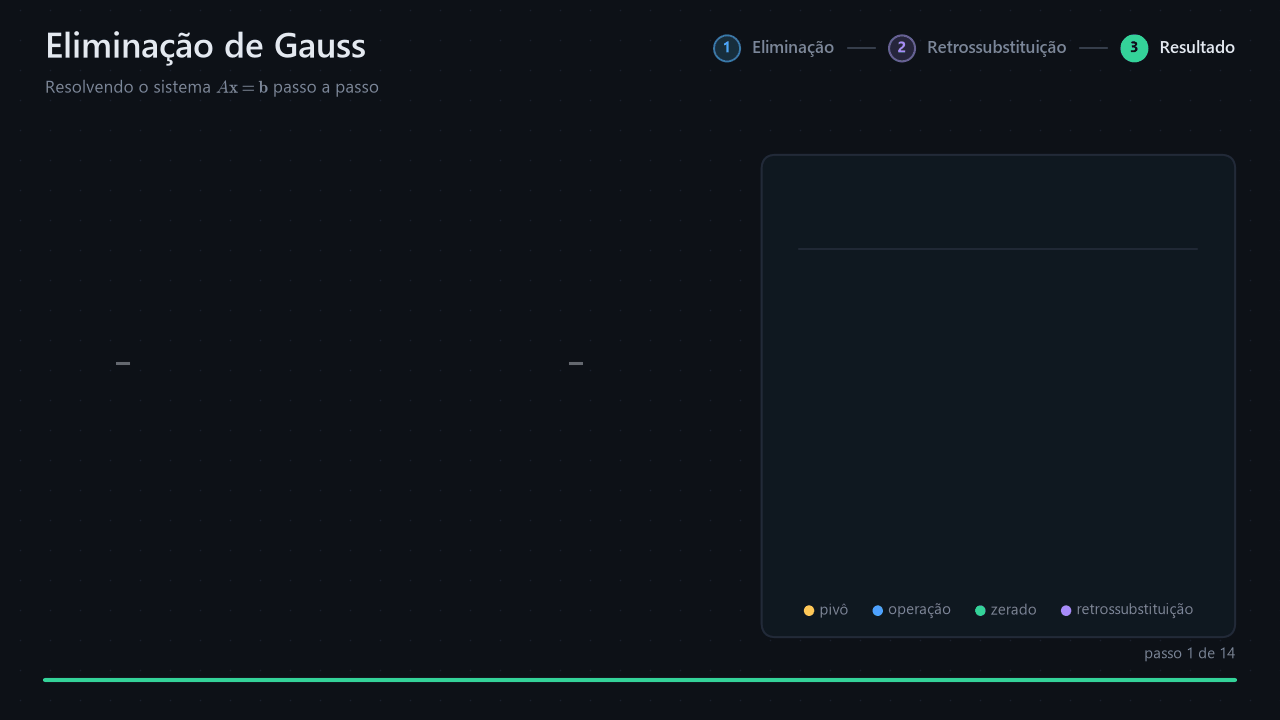

In [6]:
# Uma paleta so para o GIF inteiro (evita cores piscando entre quadros),
# montada a partir de uma amostra de cada passo.

print("Montando a paleta de cores...")
amostras = []
for idx, q in enumerate(quadros):
    amostras.append(renderizar(idx, q["t_anim"]))
    if q["fantasma"]:
        amostras.append(renderizar(idx, T_DESCE + 0.4))
cores_puras = [AMARELO, AZUL, VERDE, ROXO, TEXTO, SUAVE, APAGADO, PAINEL, CELULA]
faixa = Image.new("RGB", (amostras[0].size[0], 200))
largura_faixa = faixa.size[0] // len(cores_puras)
for c, cor in enumerate(cores_puras):   # garante as cores do tema exatas na paleta
    faixa.paste(tuple(round(255 * v) for v in rgb(cor)),
                (c * largura_faixa, 0, (c + 1) * largura_faixa, 200))
amostras.append(faixa)
w_img = amostras[0].size[0]
montagem = Image.new("RGB", (w_img, sum(amostra.size[1] for amostra in amostras)))
y_colagem = 0
for amostra in amostras:
    montagem.paste(amostra, (0, y_colagem))
    y_colagem += amostra.size[1]
paleta = montagem.reduce(2).quantize(colors=256, method=Image.Quantize.MEDIANCUT,
                                     dither=Image.Dither.NONE)

# Enquanto nada se mexe, o quadro anterior so fica mais tempo na tela
# em vez de ser desenhado de novo.
imagens, duracoes = [], []
passo = 1 / FPS
print("Desenhando os passos:", end=" ")
for idx, q in enumerate(quadros):
    for f in range(round(q["segundos"] * FPS)):
        t = f * passo
        if f > 0 and t - passo >= q["t_anim"] and t < q["t_saida"]:
            duracoes[-1] += 1000 * passo
            continue
        imagens.append(renderizar(idx, t).quantize(palette=paleta, dither=Image.Dither.NONE))
        duracoes.append(1000 * passo)
    print(idx + 1, end=" ", flush=True)
print()

imagens[0].save(ARQUIVO_GIF, save_all=True, append_images=imagens[1:],
                duration=[round(d) for d in duracoes], loop=0)
print(f"GIF salvo em {ARQUIVO_GIF} ({sum(duracoes) / 1000:.0f} s, {len(imagens)} imagens)")
display(ImagemNotebook(filename=ARQUIVO_GIF))
